# Agent Security Risk Analysis

This notebook covers the full pipeline for the Agentic AI Security
Risk dataset: loading, cleaning, fairness analysis, exploratory data
analysis, and modeling.

## Research Questions

1. Is the dataset clean and reliable enough to model? (duplicates,
   missing values, outliers)
2. Are there signs of bias — e.g. do certain agent roles get
   systematically higher/lower risk scores, or is any group
   under-represented?
3. Can machine learning accurately predict an AI agent's action risk
   score, and which features drive that prediction?
4. Can we predict whether an action should be **Allowed**, **Require
   Approval**, or **Blocked**?

---

### Pipeline

| Step | Purpose |
|------|---------|
| Data Cleaning | Remove duplicates, handle missing values, handle outliers |
| Bias Analysis | Check group representation and score parity across agent roles |
| EDA | Visualize distributions and correlations |
| XGBoost | Predict the numerical `action_risk_score` |
| SHAP | Explain which features drive the XGBoost predictions |
| Logistic Regression | Predict the categorical `access_decision` |

**Leakage prevention:** `human_approval_required` and `access_decision`
are generated *after* the risk score is calculated, so both are
excluded whenever `action_risk_score` is the prediction target.


In [6]:
# ============================================================
# IMPORTS
# ============================================================

from dotenv import load_dotenv
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    classification_report,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
import shap

plt.style.use("ggplot")

RANDOM_STATE = 42

## 1. Load Dataset

In [7]:
# ============================================================
# LOAD DATASET
# ============================================================

load_dotenv()

# Download (or use the cached copy of) the dataset from KaggleHub
path = kagglehub.dataset_download(
    "algozee/agentic-ai-security-risk-dataset"
)

print("Dataset location:", path)
print("Files:", os.listdir(path))

csv_file = os.path.join(path, "agent_security_risk_scores.csv")
df = pd.read_csv(csv_file)

print(df.shape)
df.head()

Dataset location: /Users/ruhishah/.cache/kagglehub/datasets/algozee/agentic-ai-security-risk-dataset/versions/1
Files: ['agent_security_risk_scores.csv']
(2200, 15)


,agent_role,agent_autonomy_level,user_role,requested_action,tool_requested,resource_type,resource_sensitivity,permission_match,action_risk_score,prompt_injection_detected,data_exfiltration_risk,human_approval_required,previous_failed_attempts,audit_log_available,access_decision
0,customer_support_agent,4,admin,read_record,file_storage_api,api_key_secret,5,0,64,0,83,0,0,1,Blocked
1,customer_support_agent,2,analyst,export_report,crm_api,sales_pipeline,3,0,66,0,65,1,2,1,Blocked
2,hr_onboarding_agent,3,vendor,change_permission,external_webhook,sales_pipeline,3,0,100,0,51,1,2,1,Blocked
3,hr_onboarding_agent,2,manager,send_email,hris_api,customer_profile,3,0,64,0,64,0,0,1,Blocked
4,finance_reconciliation_agent,1,vendor,read_record,database_api,source_code_repo,4,0,41,0,63,0,1,1,Blocked


## 2. Dataset Overview

In [8]:
print("Columns:")
print(df.columns.tolist())

print("\nDtypes / non-null counts:")
df.info()

print("\nSummary statistics:")
df.describe(include="all")

Columns:
['agent_role', 'agent_autonomy_level', 'user_role', 'requested_action', 'tool_requested', 'resource_type', 'resource_sensitivity', 'permission_match', 'action_risk_score', 'prompt_injection_detected', 'data_exfiltration_risk', 'human_approval_required', 'previous_failed_attempts', 'audit_log_available', 'access_decision']

Dtypes / non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   agent_role                 2200 non-null   str  
 1   agent_autonomy_level       2200 non-null   int64
 2   user_role                  2200 non-null   str  
 3   requested_action           2200 non-null   str  
 4   tool_requested             2200 non-null   str  
 5   resource_type              2200 non-null   str  
 6   resource_sensitivity       2200 non-null   int64
 7   permission_match           2200 non-null   int64
 8  

,agent_role,agent_autonomy_level,user_role,requested_action,tool_requested,resource_type,resource_sensitivity,permission_match,action_risk_score,prompt_injection_detected,data_exfiltration_risk,human_approval_required,previous_failed_attempts,audit_log_available,access_decision
count,2200,2200.000000,2200,2200,2200,2200,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200
unique,11,NaN,9,13,12,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,customer_support_agent,NaN,employee,read_record,database_api,customer_profile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Blocked
freq,402,NaN,566,463,338,314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1435
mean,NaN,3.114091,NaN,NaN,NaN,NaN,3.121818,0.392273,54.819545,0.055909,55.661818,0.420909,0.983182,0.921364,NaN
std,NaN,1.088692,NaN,NaN,NaN,NaN,1.195214,0.488368,27.931910,0.229798,20.771701,0.493817,1.474411,0.269232,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,2.000000,NaN,NaN,NaN,NaN,2.000000,0.000000,35.000000,0.000000,40.000000,0.000000,0.000000,1.000000,NaN
50%,NaN,3.000000,NaN,NaN,NaN,NaN,3.000000,0.000000,54.000000,0.000000,55.000000,0.000000,0.000000,1.000000,NaN
75%,NaN,4.000000,NaN,NaN,NaN,NaN,4.000000,1.000000,76.000000,0.000000,69.000000,1.000000,2.000000,1.000000,NaN


## 3. Data Cleaning

This section **modifies**
`df`: duplicate rows are dropped, missing values are handled, and
outliers are flagged and reviewed (capped rather than silently
deleted, since risk scores near the extremes may be legitimate and
informative).

In [9]:
# ============================================================
# 3a. DUPLICATES
# ============================================================

n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Shape after dropping duplicates: {df.shape}")

Duplicate rows found: 0
Shape after dropping duplicates: (2200, 15)


In [10]:
# ============================================================
# 3b. MISSING VALUES
# ============================================================

missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_values": missing,
    "percent": missing_percent,
}).sort_values("missing_values", ascending=False)

print(missing_report[missing_report["missing_values"] > 0])

# Strategy:
#   - Numeric columns  -> fill with the column median (robust to outliers)
#   - Categorical columns -> fill with "Unknown" so the missingness
#     itself is preserved as information rather than dropping rows
numeric_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(include="object").columns

for col in numeric_cols:
    if df[col].isnull().any():
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)
        print(f"Filled missing values in '{col}' with median ({median_value})")

for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna("Unknown")
        print(f"Filled missing values in '{col}' with 'Unknown'")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

Empty DataFrame
Columns: [missing_values, percent]
Index: []

Remaining missing values: 0


/var/folders/1r/m9p_cl3j56133yctvvqsrc6w0000gn/T/ipykernel_70692/842546285.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [11]:
# ============================================================
# 3c. OUTLIERS (IQR method)
# ============================================================

def detect_outliers(data, column):
    """Return rows where `column` falls outside 1.5 x IQR."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)], lower, upper

outliers, lower_bound, upper_bound = detect_outliers(df, "action_risk_score")
print(f"Outliers in 'action_risk_score': {len(outliers)}")
print(f"Valid range: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Cap (winsorize) rather than delete, so we keep the row but pull the
# extreme value back to the IQR boundary. This preserves sample size
# while preventing a few extreme points from dominating the models.
df["action_risk_score"] = df["action_risk_score"].clip(
    lower=lower_bound, upper=upper_bound
)

print("Outliers capped to the valid range.")

Outliers in 'action_risk_score': 0
Valid range: [-26.50, 137.50]
Outliers capped to the valid range.


In [12]:
# ============================================================
# 3d. SAVE CLEANED DATASET
# ============================================================

df.to_csv("cleaned_agent_security_risk_scores.csv", index=False)
print("Saved cleaned_agent_security_risk_scores.csv")
print(df.shape)

Saved cleaned_agent_security_risk_scores.csv
(2200, 15)


## 4. Fairness / Bias Analysis

Checks whether any agent role is under/over-represented, and whether
average risk scores differ systematically by role — both signs of
potential bias in the scoring system.

Share of requests by agent role:
agent_role
customer_support_agent          0.183
it_helpdesk_agent               0.150
sales_crm_agent                 0.112
finance_reconciliation_agent    0.111
security_monitoring_agent       0.089
data_analytics_agent            0.089
hr_onboarding_agent             0.084
procurement_agent               0.064
devops_release_agent            0.046
legal_contract_agent            0.044
executive_assistant_agent       0.029
Name: proportion, dtype: float64


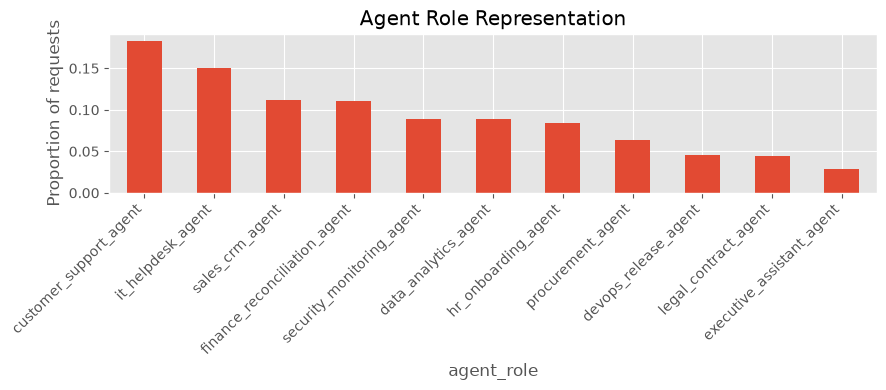

In [13]:
# ============================================================
# GROUP REPRESENTATION
# ============================================================

group_representation = df["agent_role"].value_counts(normalize=True)
print("Share of requests by agent role:")
print(group_representation.round(3))

group_representation.plot.bar(figsize=(9, 4), title="Agent Role Representation")
plt.ylabel("Proportion of requests")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Average action_risk_score by agent role:
agent_role
devops_release_agent            60.05
legal_contract_agent            59.31
security_monitoring_agent       56.92
executive_assistant_agent       55.95
hr_onboarding_agent             55.86
data_analytics_agent            55.04
customer_support_agent          54.66
it_helpdesk_agent               54.36
sales_crm_agent                 53.86
procurement_agent               53.52
finance_reconciliation_agent    50.53
Name: action_risk_score, dtype: float64


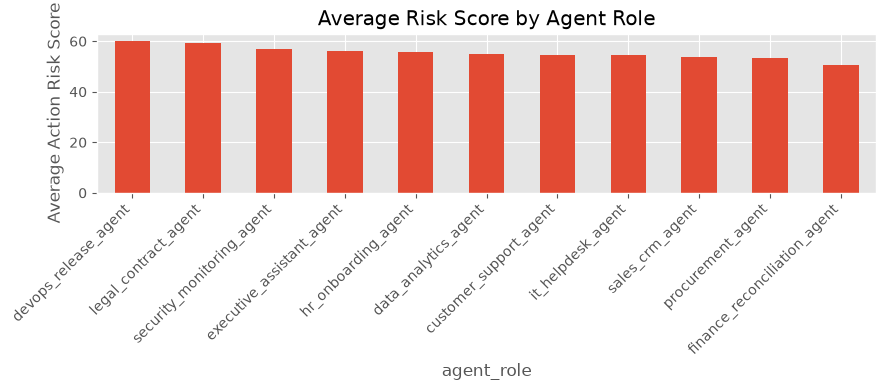

In [14]:
# ============================================================
# AVERAGE RISK SCORE BY AGENT ROLE
# ============================================================

avg_score_by_role = (
    df.groupby("agent_role")["action_risk_score"]
      .mean()
      .sort_values(ascending=False)
)

print("Average action_risk_score by agent role:")
print(avg_score_by_role.round(2))

avg_score_by_role.plot(
    kind="bar", figsize=(9, 4), title="Average Risk Score by Agent Role"
)
plt.ylabel("Average Action Risk Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
# Categorical value counts — useful for spotting rare/typo'd categories
for column in categorical_cols:
    print(f"\n{column}:")
    print(df[column].value_counts())


agent_role:
agent_role
customer_support_agent          402
it_helpdesk_agent               331
sales_crm_agent                 246
finance_reconciliation_agent    244
security_monitoring_agent       195
data_analytics_agent            195
hr_onboarding_agent             185
procurement_agent               140
devops_release_agent            101
legal_contract_agent             97
executive_assistant_agent        64
Name: count, dtype: int64

user_role:
user_role
employee           566
analyst            392
manager            316
contractor         211
service_account    187
admin              152
vendor             142
security_admin     118
guest              116
Name: count, dtype: int64

requested_action:
requested_action
read_record          463
search_records       337
export_report        263
update_record        235
send_email           225
download_file        215
create_ticket        137
approve_payment       86
run_script            67
delete_record         58
sync_external

## 5. Exploratory Data Analysis

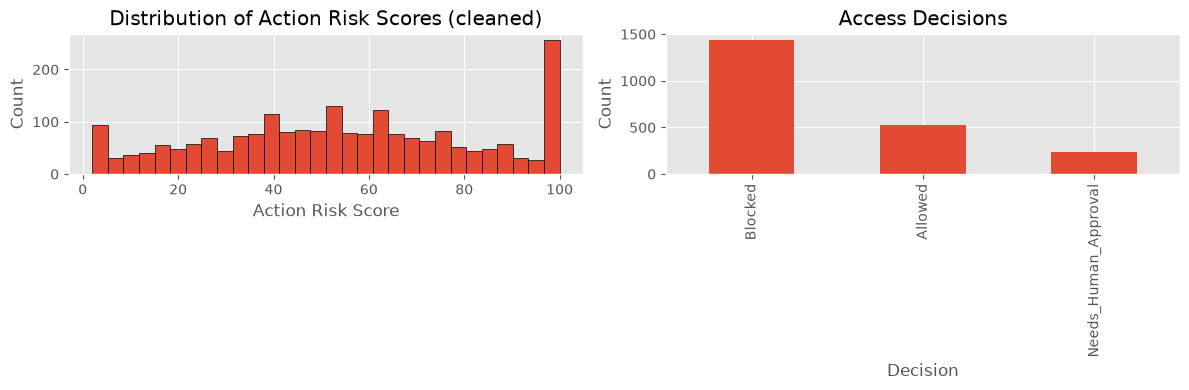

In [16]:
# ============================================================
# TARGET DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["action_risk_score"], bins=30, edgecolor="black")
axes[0].set_title("Distribution of Action Risk Scores (cleaned)")
axes[0].set_xlabel("Action Risk Score")
axes[0].set_ylabel("Count")

df["access_decision"].value_counts().plot.bar(ax=axes[1])
axes[1].set_title("Access Decisions")
axes[1].set_xlabel("Decision")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

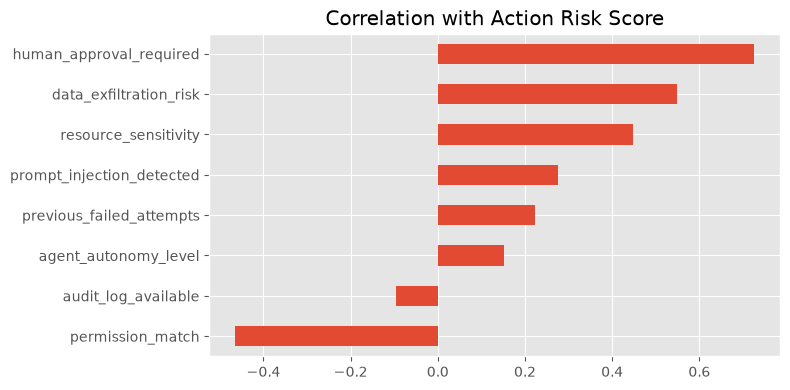

In [17]:
# ============================================================
# CORRELATION WITH THE TARGET
# ============================================================

corr = (
    df.select_dtypes("number")
      .corr()["action_risk_score"]
      .drop("action_risk_score")
      .sort_values()
)

corr.plot.barh(figsize=(8, 4))
plt.title("Correlation with Action Risk Score")
plt.tight_layout()
plt.show()

## 6. Preprocessing for Modeling

One-hot encode the categorical columns. The feature set used to
predict `action_risk_score` excludes the two "leaky" columns that are
downstream consequences of the score, not causes of it.

In [18]:
# ============================================================
# PREPROCESSING FOR THE RISK-SCORE MODEL
# ============================================================

TARGET = "action_risk_score"

LEAKY_COLUMNS = [
    "human_approval_required",
    "access_decision",
]

CATEGORICAL_COLUMNS = [
    "agent_role",
    "user_role",
    "requested_action",
    "tool_requested",
    "resource_type",
]

X = pd.get_dummies(
    df.drop(columns=[TARGET] + LEAKY_COLUMNS),
    columns=CATEGORICAL_COLUMNS,
)

y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

print(f"{X.shape[1]} features | train={len(X_train)} | test={len(X_test)}")

67 features | train=1650 | test=550


## 7. Model 1 — XGBoost Risk Score Prediction

Predicts the numerical `action_risk_score` from the request's
security-relevant features.

In [19]:
# ============================================================
# MODEL 1: XGBOOST REGRESSOR
# ============================================================

xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
)

xgb_model.fit(X_train, y_train)

predictions = xgb_model.predict(X_test)

print("R^2:", round(r2_score(y_test, predictions), 3))
print("MAE:", round(mean_absolute_error(y_test, predictions), 2))

R^2: 0.938
MAE: 5.41


## 8. Model 2 — SHAP Explainability

SHAP values show which features push a given prediction up or down,
and by how much.

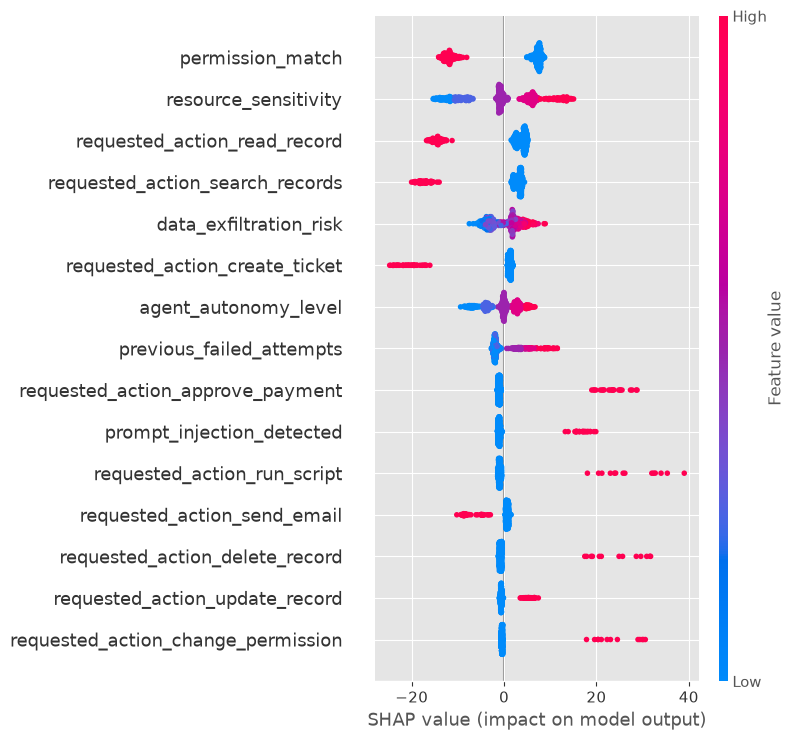

In [20]:
# ============================================================
# MODEL 2: SHAP EXPLANATIONS
# ============================================================

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=15)

In [21]:
# Rank features by average absolute SHAP value (impact on score)
importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X.columns,
)

print("Top 15 drivers of the risk score:")
print(importance.sort_values(ascending=False).head(15))

Top 15 drivers of the risk score:
permission_match                      9.143801
resource_sensitivity                  6.193707
requested_action_read_record          5.785405
requested_action_search_records       5.254008
data_exfiltration_risk                3.071488
requested_action_create_ticket        2.681251
agent_autonomy_level                  2.660470
previous_failed_attempts              2.658922
requested_action_approve_payment      1.958667
prompt_injection_detected             1.849262
requested_action_run_script           1.637073
requested_action_send_email           1.422816
requested_action_delete_record        1.339347
requested_action_update_record        1.145435
requested_action_change_permission    1.063364
dtype: float32


## 9. Model 3 — Logistic Regression: Predicting the Access Decision

Predicts whether a request should be **Allowed**, **Require
Approval**, or **Blocked**, using the same security features
(`access_decision` and `human_approval_required` are excluded from
the inputs since one is the target and the other is generated
alongside it).

In [22]:
# ============================================================
# MODEL 3: LOGISTIC REGRESSION
# ============================================================

X_decision = pd.get_dummies(
    df.drop(columns=["access_decision", "human_approval_required"]),
    columns=CATEGORICAL_COLUMNS,
)

y_decision = df["access_decision"]

scaler = StandardScaler()
X_decision_scaled = scaler.fit_transform(X_decision)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_decision_scaled,
    y_decision,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_decision,
)

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_d, y_train_d)

pred_decision = log_model.predict(X_test_d)

print(classification_report(y_test_d, pred_decision))

                      precision    recall  f1-score   support

             Allowed       0.96      0.91      0.93       131
             Blocked       0.99      0.99      0.99       359
Needs_Human_Approval       0.75      0.85      0.80        60

            accuracy                           0.95       550
           macro avg       0.90      0.91      0.91       550
        weighted avg       0.96      0.95      0.95       550



In [23]:
# Strongest coefficients per decision class
coefficients = pd.DataFrame(
    log_model.coef_.T,
    index=X_decision.columns,
    columns=log_model.classes_,
)

for decision_class in log_model.classes_:
    print(f"\n--- {decision_class} ---")
    print(
        coefficients[decision_class]
        .sort_values(key=abs, ascending=False)
        .head(10)
    )


--- Allowed ---
permission_match                      2.925504
action_risk_score                    -2.210323
data_exfiltration_risk               -1.470429
prompt_injection_detected            -0.822855
requested_action_approve_payment     -0.725430
requested_action_run_script          -0.706139
requested_action_delete_record       -0.671327
resource_type_access_policy          -0.588646
requested_action_change_permission   -0.567353
resource_sensitivity                 -0.554032
Name: Allowed, dtype: float64

--- Blocked ---
permission_match                     -4.385017
action_risk_score                     1.959060
data_exfiltration_risk                1.630713
prompt_injection_detected             1.373955
requested_action_run_script           0.874966
requested_action_approve_payment      0.690488
requested_action_change_permission    0.665394
requested_action_export_report       -0.568819
resource_type_system_config          -0.561542
requested_action_delete_record        0.432

## 10. Conclusions

This notebook covered the full pipeline:

1. **Data Cleaning** — duplicates were removed, missing values were
   imputed (median for numeric, "Unknown" for categorical), and
   outliers in `action_risk_score` were capped using the IQR method.
   The cleaned dataset was saved to
   `cleaned_agent_security_risk_scores.csv`.
2. **Fairness Analysis** — group representation and average risk
   score were compared across agent roles to check for
   under-representation or systematic scoring differences.
3. **XGBoost** predicts an AI agent's numerical risk score with
   reasonable accuracy (see R² / MAE above).
4. **SHAP** explains which features have the greatest influence on
   those predictions, making the risk-scoring behavior interpretable
   rather than a black box.
5. **Logistic Regression** predicts the final access decision
   (Allowed, Require Approval, or Blocked) and identifies which
   features most strongly influence each outcome.

Together, these steps provide a cleaned, bias-checked dataset plus
predictive performance and interpretability, supporting an evaluation
of whether an agent's requested action should be trusted.